# Natural Disaster Severity Prediction — EDA

This notebook calls functions from `eda.py`. Each `section_*` function returns `(figs, findings)`:
- `figs` is a list of matplotlib Figures rendered inline
- `findings` is a structured dict that the function also prints as a **Key findings** block

The final cell aggregates every section's findings into one summary.

**Dataset**: 2,248 regions × 5,480 daily rows (train) / 91 daily rows (test)  
**Target**: Weekly severity score 0–5 (~67% zeros)  
**Task**: Predict pred_week1–pred_week5 per region  
**Metric**: Macro-averaged MAE across 5 horizons

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'code'))
import eda

import warnings
warnings.filterwarnings('ignore')

ALL_FINDINGS = []  # accumulated across sections for the final aggregated cell

## Section 1: Data Overview
Check shapes, dtypes, null counts, and row/region uniformity.

In [6]:
_, findings1 = eda.section_data_overview()
ALL_FINDINGS.append(findings1)

SECTION 1: DATA OVERVIEW

Shape — train sample: (197280, 20)   test: (204568, 19)

Train columns : ['region_id', 'date', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'score', 'month', 'day_of_year', 'week_of_year']
Test  columns : ['region_id', 'date', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'month', 'day_of_year', 'week_of_year']
Sub   columns : ['region_id', 'pred_week1', 'pred_week2', 'pred_week3', 'pred_week4', 'pred_week5']

Train sample dtypes:
region_id        object
date             object
prec            float64
surf_pre        float64
humidity        float64
tmp             float64
dp_tmp          float64
wb_tmp          float64
tmp_max         float64
tmp_min         float64
tmp_range       float64
surf_tmp        float64
wind            float64
wind_max      

## Section 2: Score Distribution
Overall 0–5 histogram, per-region mean distribution, ACF/PACF (determines useful lag depth).

In [4]:
print('Loading all scored rows from train (this takes ~1 min for 12M rows)...')
scored_df = eda._load_full_train_scored()
print(f'Loaded {len(scored_df):,} scored rows')

Loading all scored rows from train (this takes ~1 min for 12M rows)...
Loaded 1,757,936 scored rows



  Section 2 key findings — Score Distribution
  • Zero rate (all regions, all weeks): 59.63%
  • Mean score (non-zero rows only): 2.070
  • Score frequency (% of weeks): s=0: 59.63%, s=1: 17.26%, s=2: 10.60%, s=3: 6.74%, s=4: 3.95%, s=5: 1.82%
  • Per-region mean score: global mean = 0.836
  • ACF for R1 remains > 0.05 for all 40 lags shown



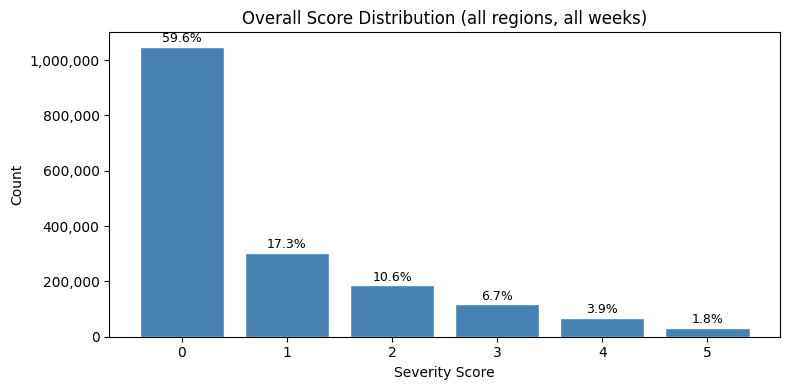

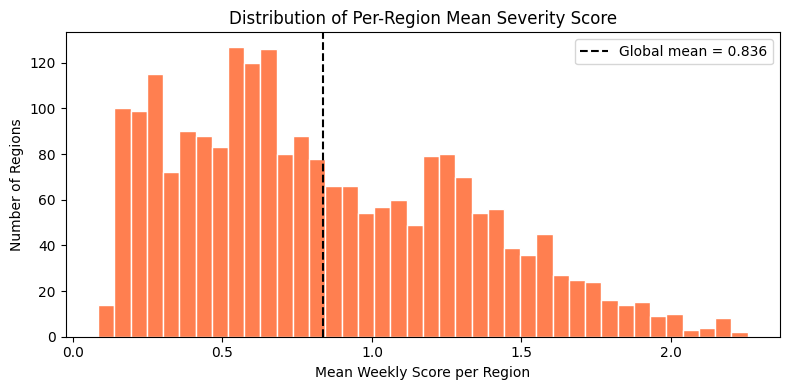

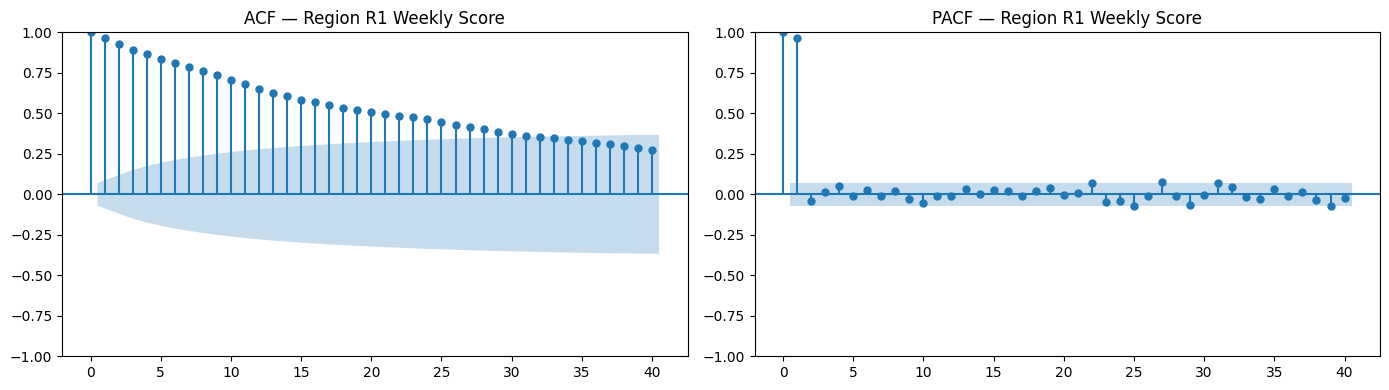

In [4]:
figs2, findings2 = eda.section_score_distribution(scored_df)
ALL_FINDINGS.append(findings2)
for fig in figs2:
    fig.show()

## Section 3: Feature Distributions
Histograms, correlation heatmap, feature-score correlation ranking.

In [5]:
print('Loading 100-region sample for feature distributions...')
train_sample = eda._load_train_sample(n_regions=100)
print(f'Sample shape: {train_sample.shape}')

Loading 100-region sample for feature distributions...
Sample shape: (421960, 20)



  Section 3 key findings — Feature Distributions
  • Top features by |corr(feature, score)|: tmp_range(+0.206), surf_pre(-0.183), tmp_max(+0.097)
  • Top collinear pairs (|r| highest, may inflate variance in linear models): wb_tmp↔dp_tmp(+1.00), surf_tmp↔tmp(+1.00), tmp↔tmp_max(+0.98), tmp_min↔tmp(+0.98), surf_tmp↔tmp_max(+0.98)



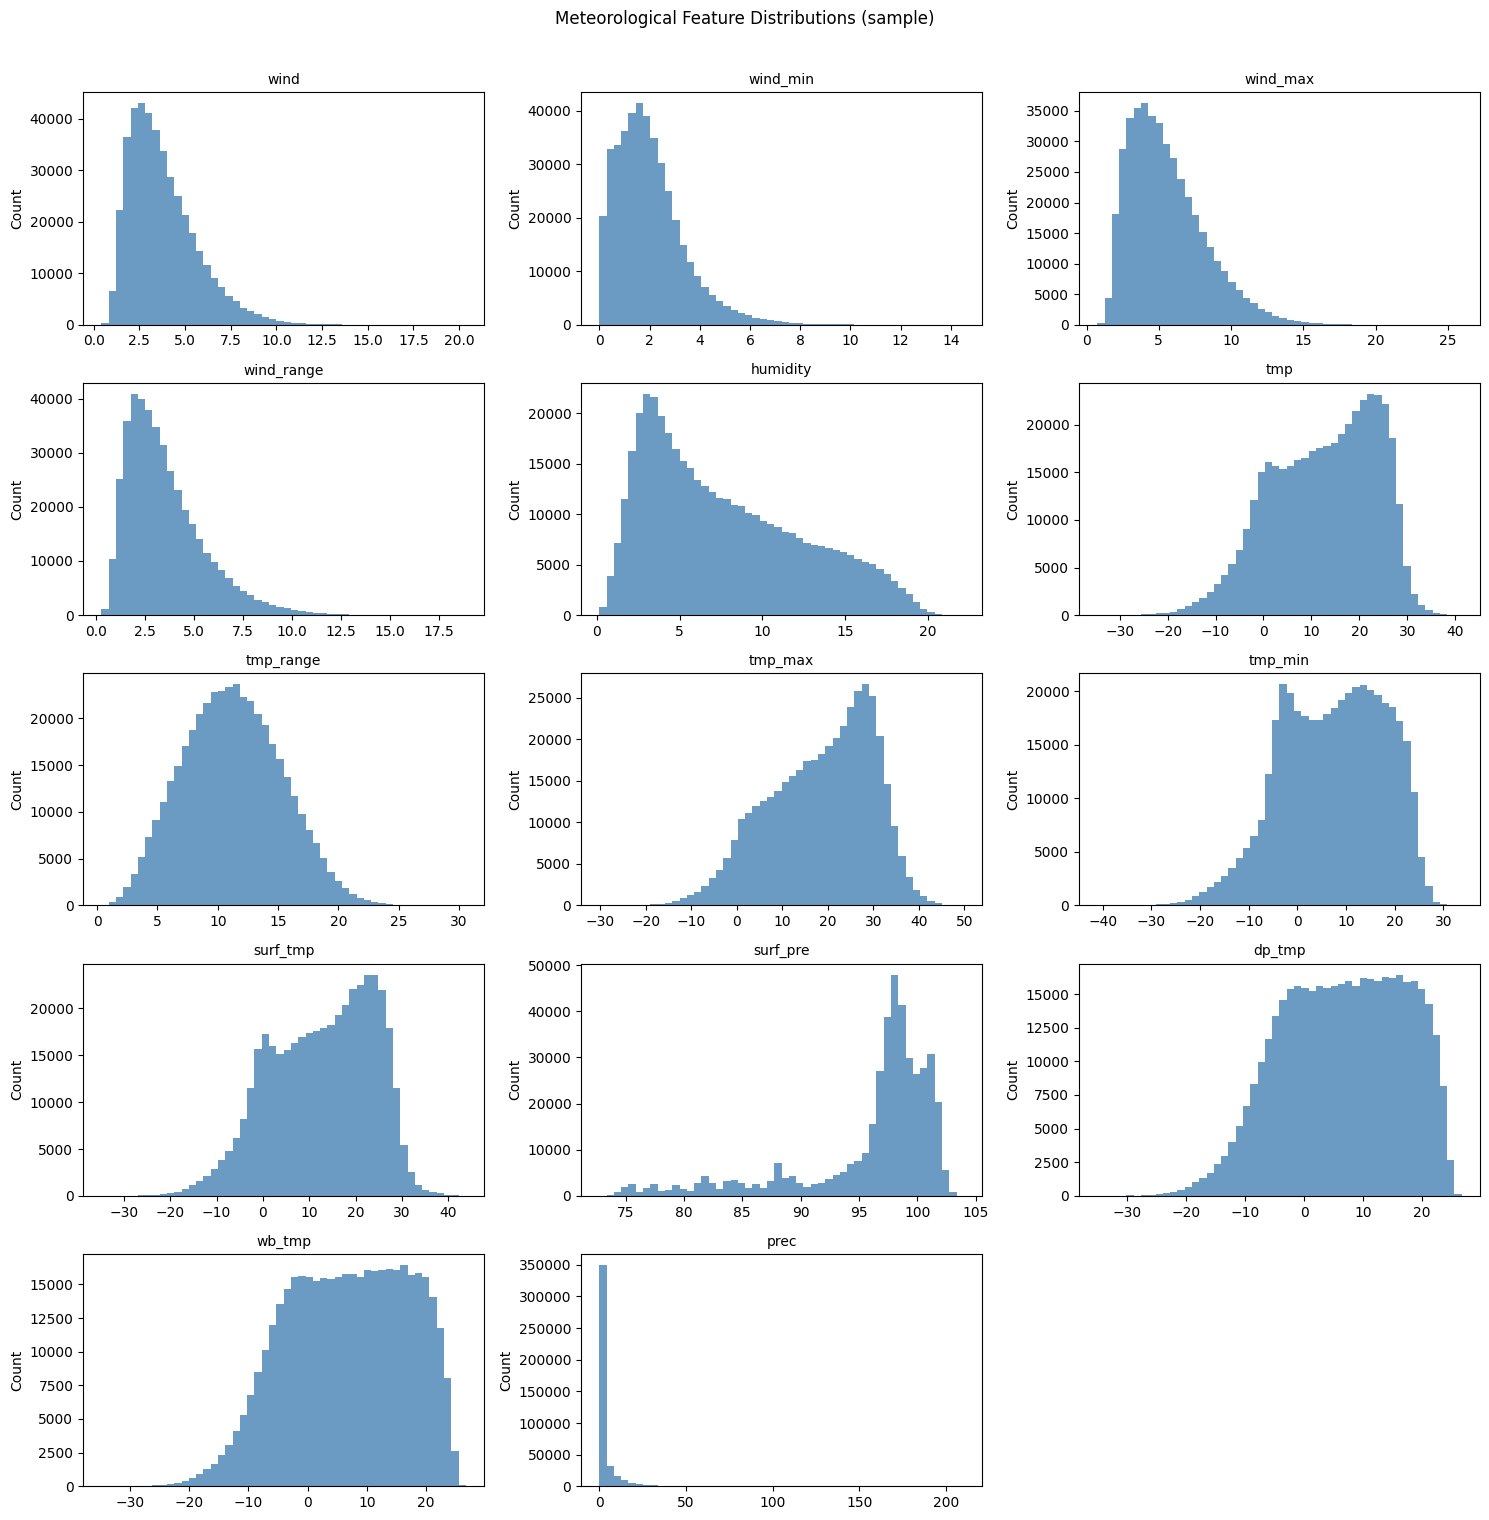

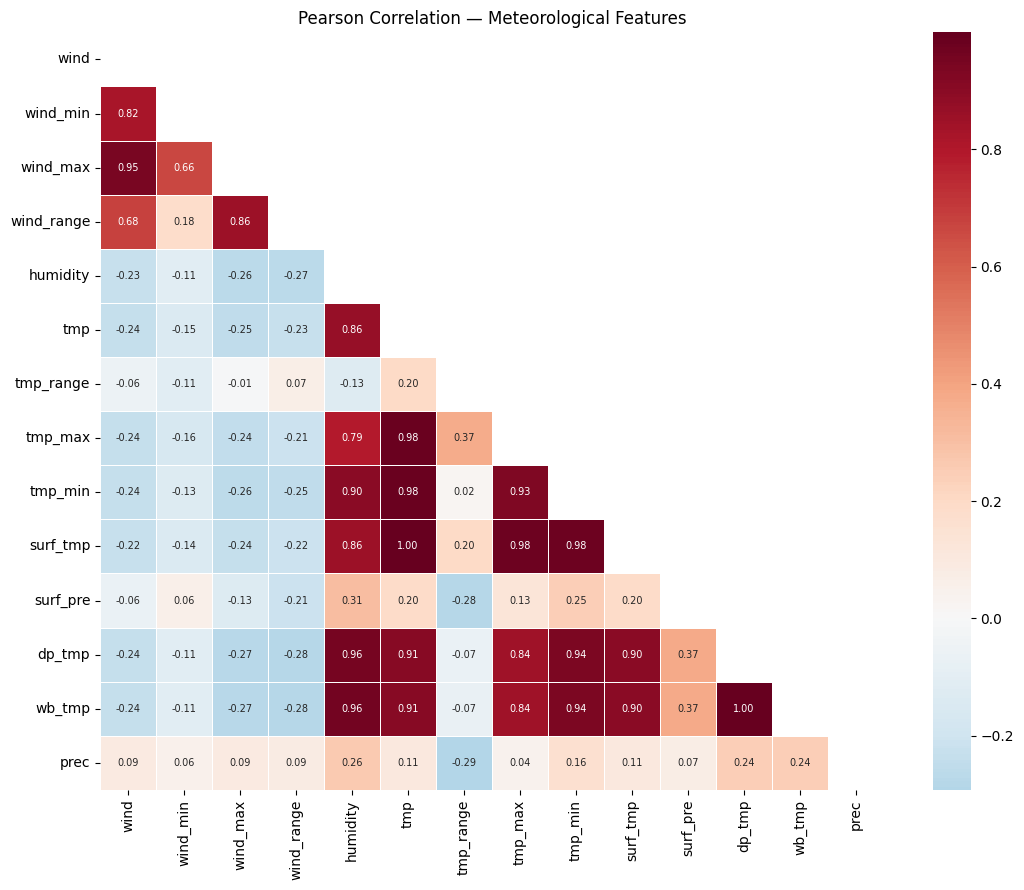

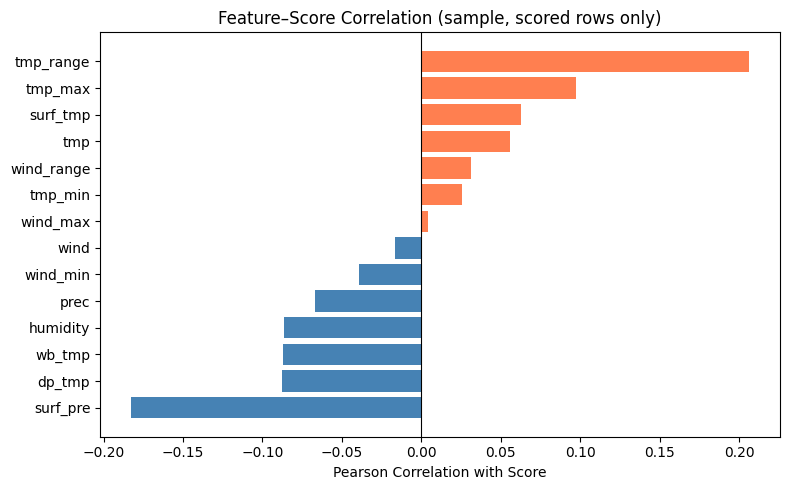

In [6]:
figs3, findings3 = eda.section_feature_distributions(train_sample)
ALL_FINDINGS.append(findings3)
for fig in figs3:
    fig.show()

## Section 4: Time-Series Visualization
Per-region daily features with weekly score overlay; average score by calendar month.

Loading train sample for 5 specific regions...

  Section 4 key findings — Time-Series Viz
  • Per-region time-series rendered for: ['R1', 'R500', 'R2000']
  • Peak severity month: Nov (mean score = 1.251)
  • Trough severity month: Mar (mean score = 0.905)
  • Seasonal amplitude (peak − trough) = 0.346



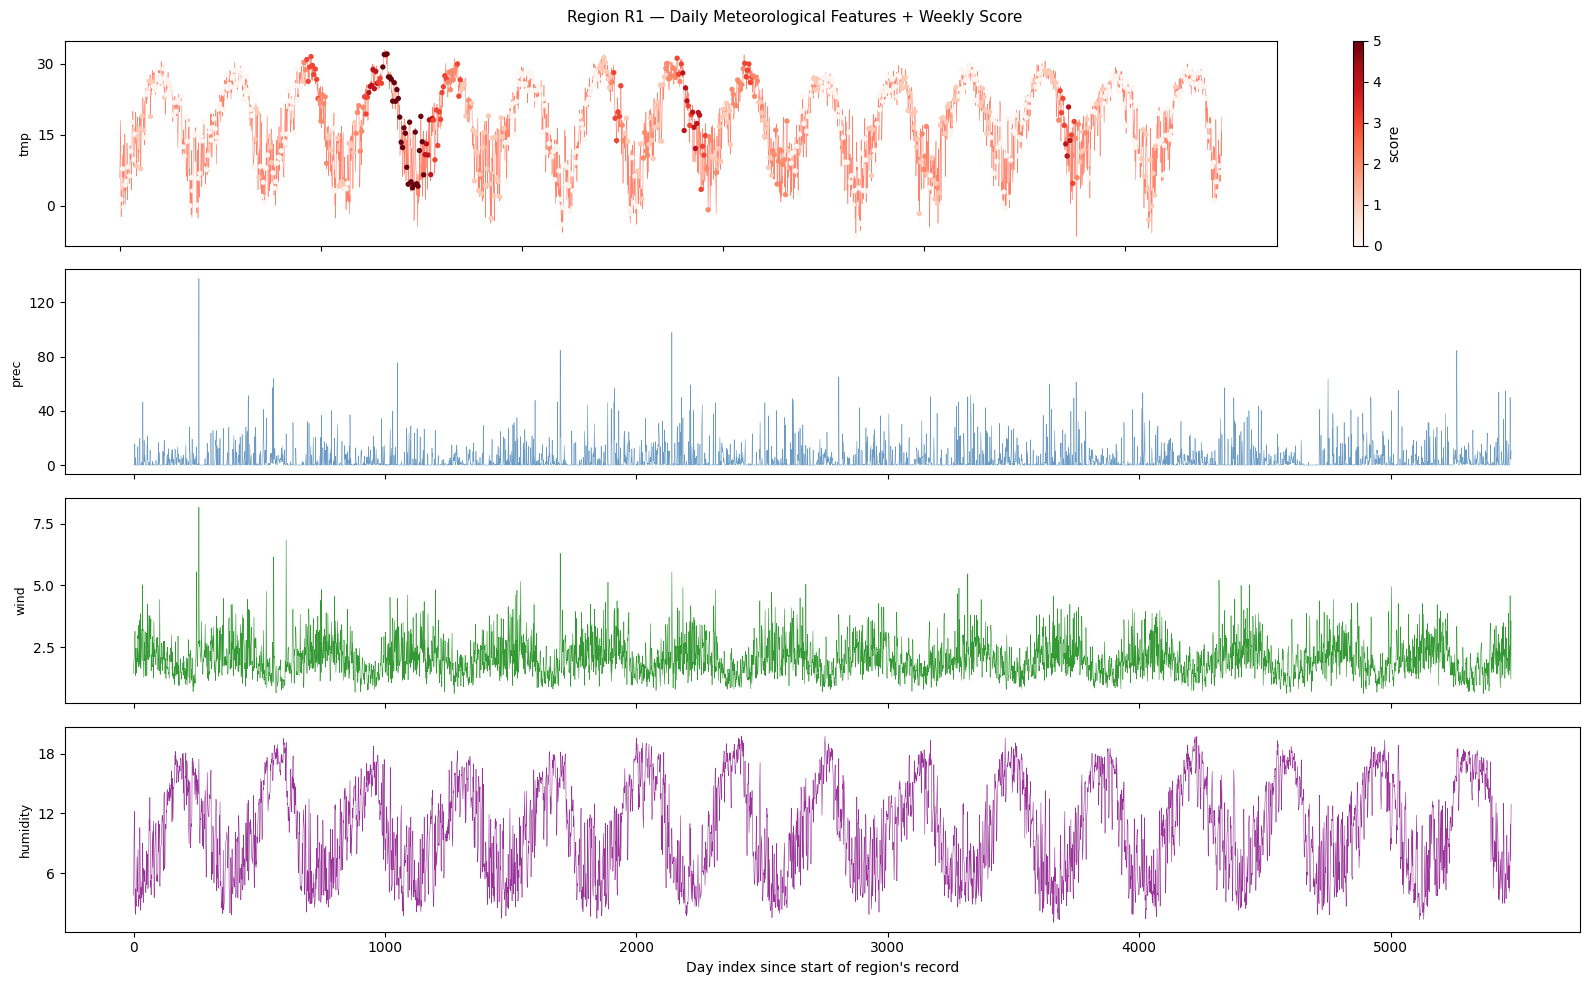

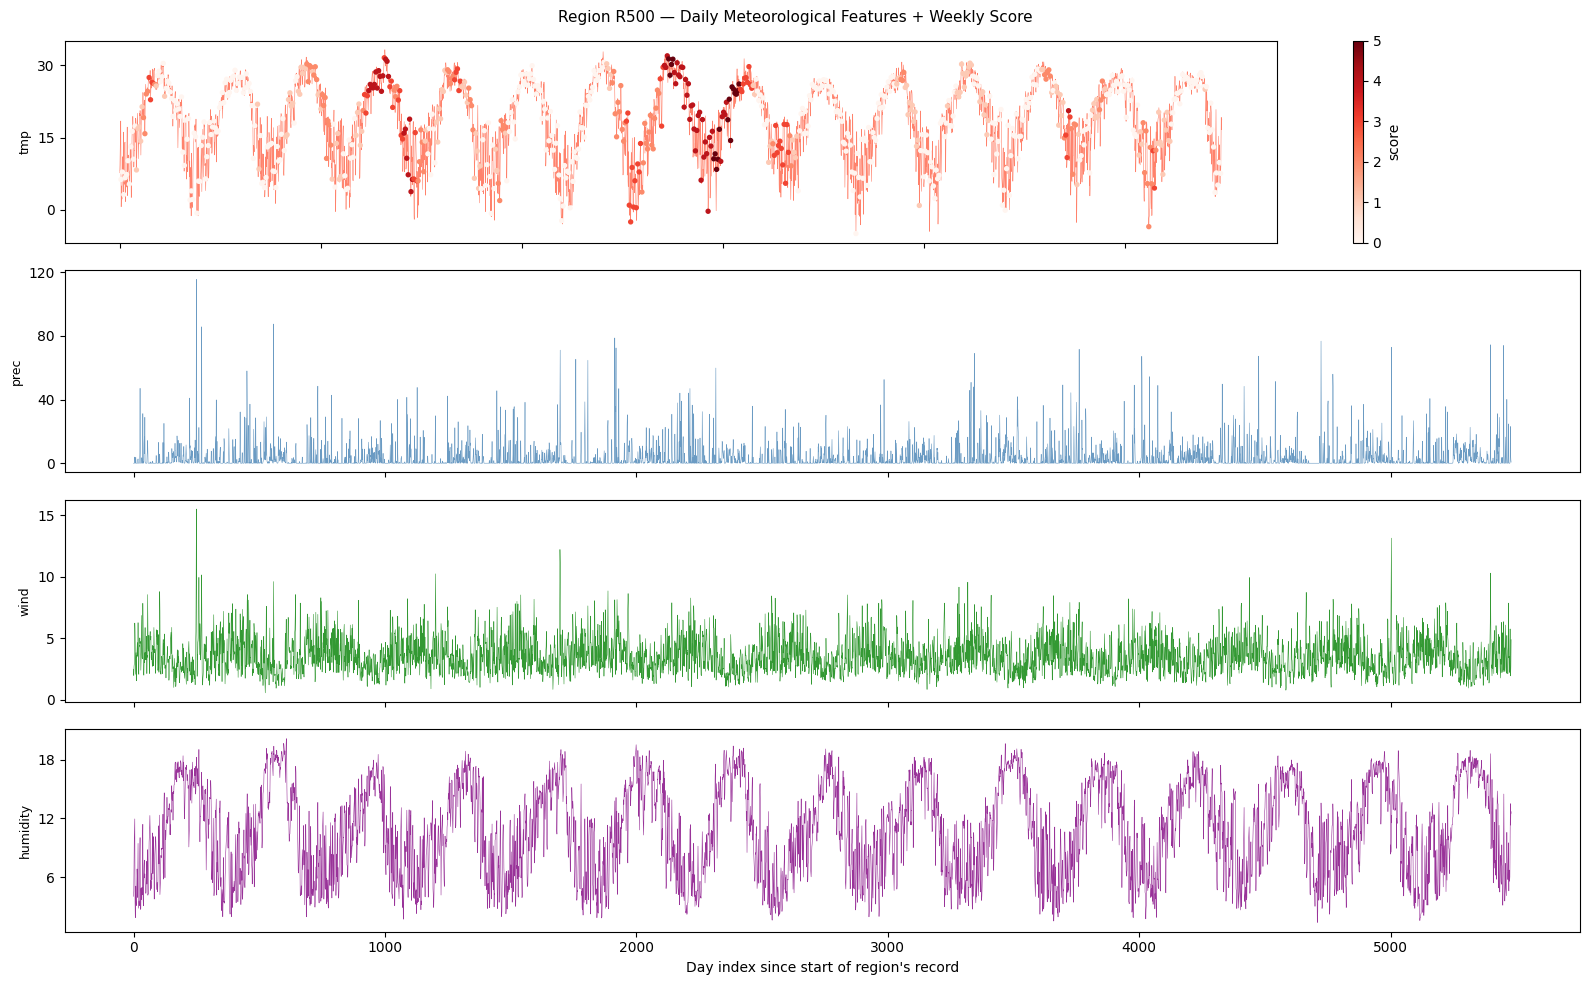

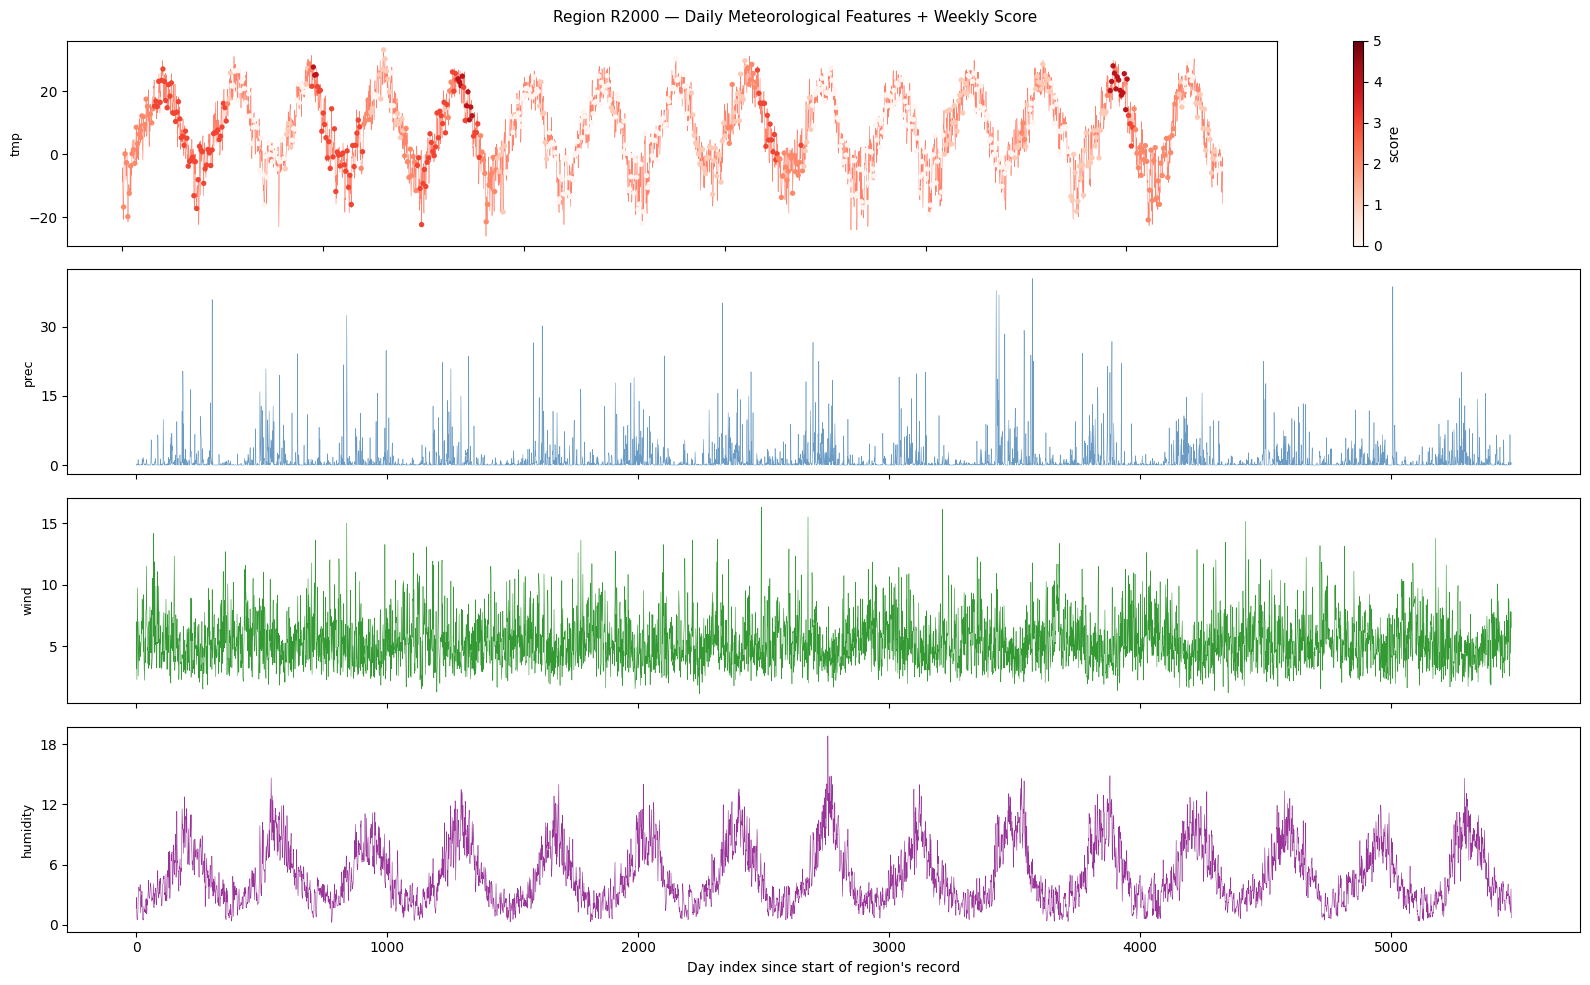

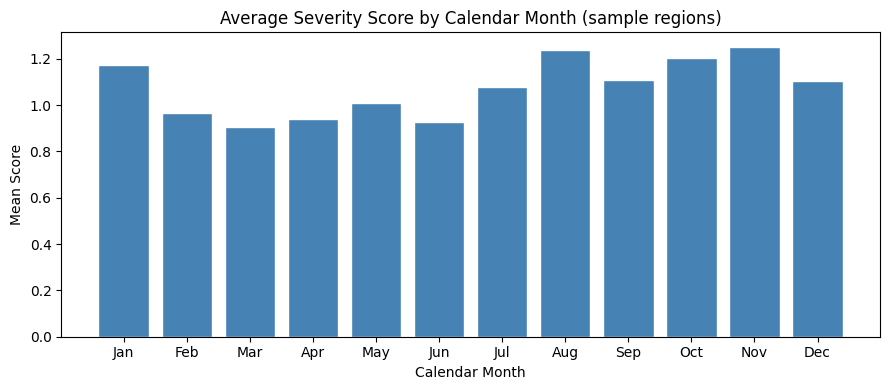

In [7]:
figs4, findings4 = eda.section_timeseries_viz()
ALL_FINDINGS.append(findings4)
for fig in figs4:
    fig.show()

## Section 5: Weekly Aggregation Patterns
Feature-score correlations on weekly anchors, score by week-of-year, score by season.


  Section 5 key findings — Weekly Patterns
  • Top + feature↔score corr: surf_tmp(+0.103), tmp_max(+0.134), tmp_range(+0.221)
  • Top − feature↔score corr: surf_pre(-0.156), prec(-0.061), dp_tmp(-0.056)
  • Peak severity week-of-year: 32 (mean=0.972); trough: 21 (mean=0.725)
  • Highest-severity season: JJA (mean=0.864)



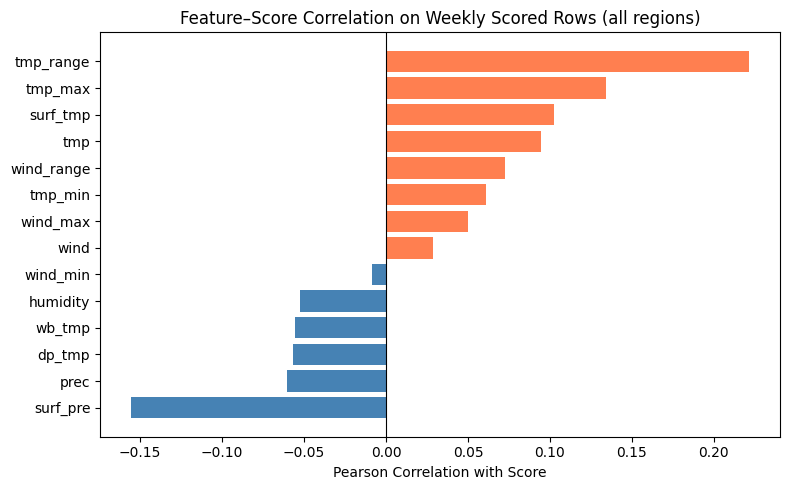

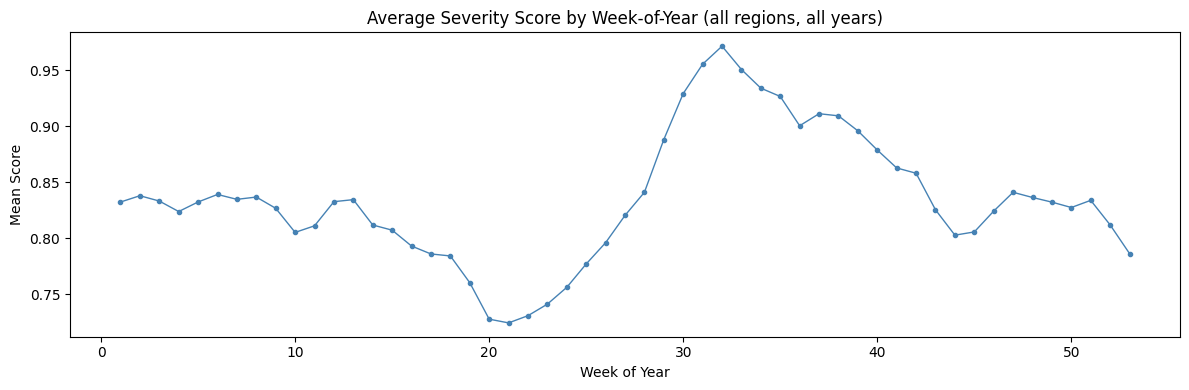

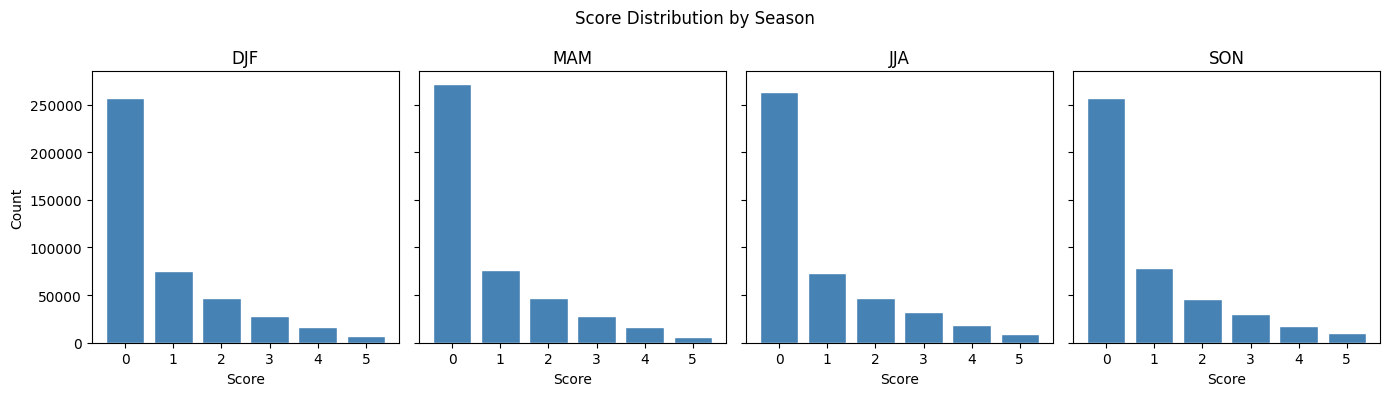

In [8]:
figs5, findings5 = eda.section_weekly_patterns(scored_df)
ALL_FINDINGS.append(findings5)
for fig in figs5:
    fig.show()

## Section 6: Test Window Analysis
Region overlap + train vs. test feature box plots.

Test regions: 2248
Train regions: 2248
Test regions NOT in train: 0

  Section 6 key findings — Test Window Analysis
  • Test regions: 2248; train regions: 2248; test regions missing from train: 0
  • Top features by |test_median − train_median|: surf_tmp(+6.380), tmp(+6.200), tmp_min(+6.050)



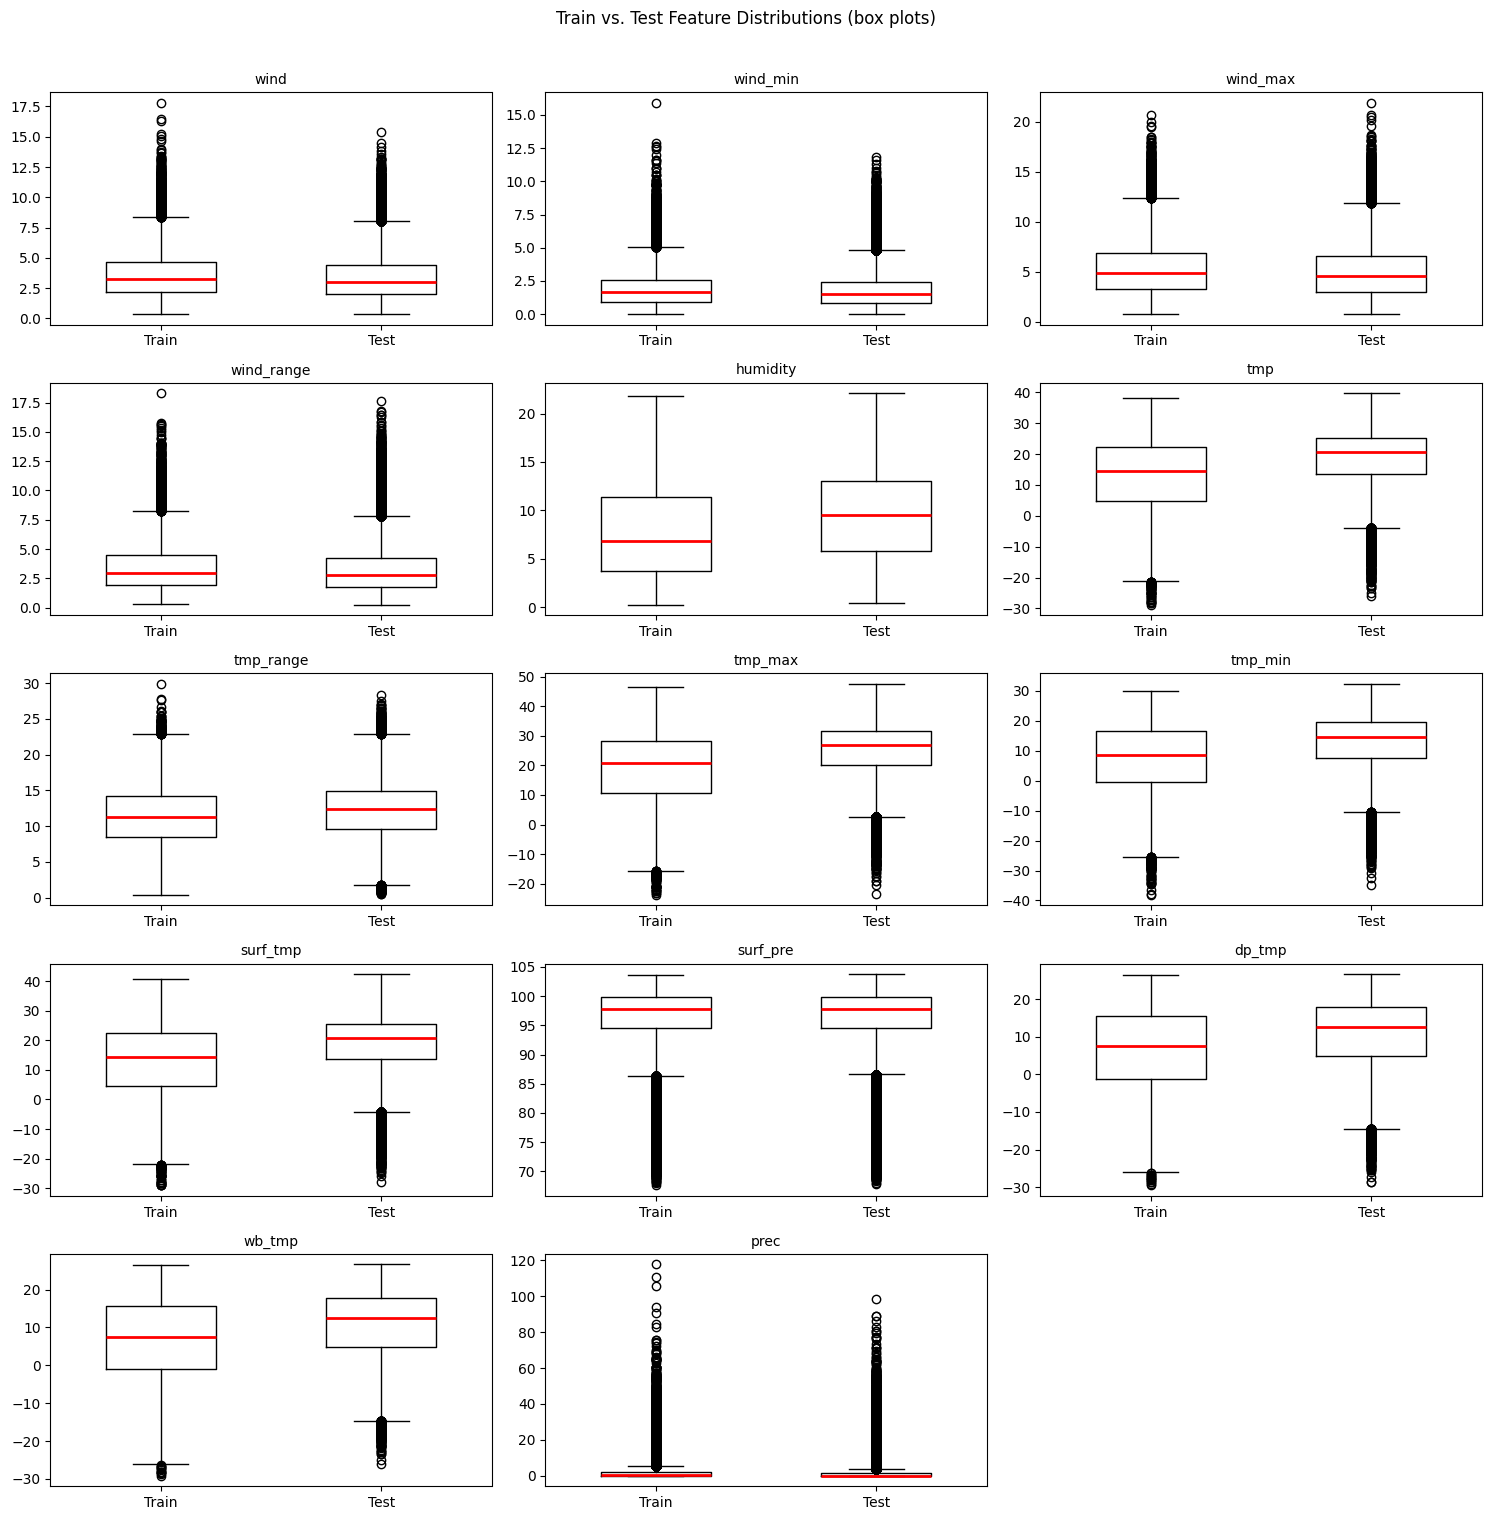

In [9]:
figs6, findings6 = eda.section_test_analysis(scored_df)
ALL_FINDINGS.append(findings6)
for fig in figs6:
    fig.show()

## Section 7: Outlier Analysis (p1/p99 winsorization candidates)
Per-feature p1/p99 thresholds, outlier rates, top-5 most extreme rows. Feeds the preprocessing module.


  Section 7 key findings — Outlier Analysis
  • Top features by % above p99: prec (1.00%, p99=29.92, max=210.18), wind_min (1.00%, p99=6.41, max=14.52), tmp (1.00%, p99=30.72, max=41.39)
  • Top features by % below p1: tmp_max (1.00%, p1=-8.67, min=-30.25), tmp_min (1.00%, p1=-18.12, min=-41.15), surf_tmp (1.00%, p1=-13.40, min=-34.90)
  • Total NaN cells across all features (sample): 0
  • 5 most extreme rows for 'prec': R1939@39181-10-0=210.18, R1887@39077-10-0=188.07, R421@15143-10-0=175.04, R149@7137-01-05=0.00, R149@7137-01-06=0.00



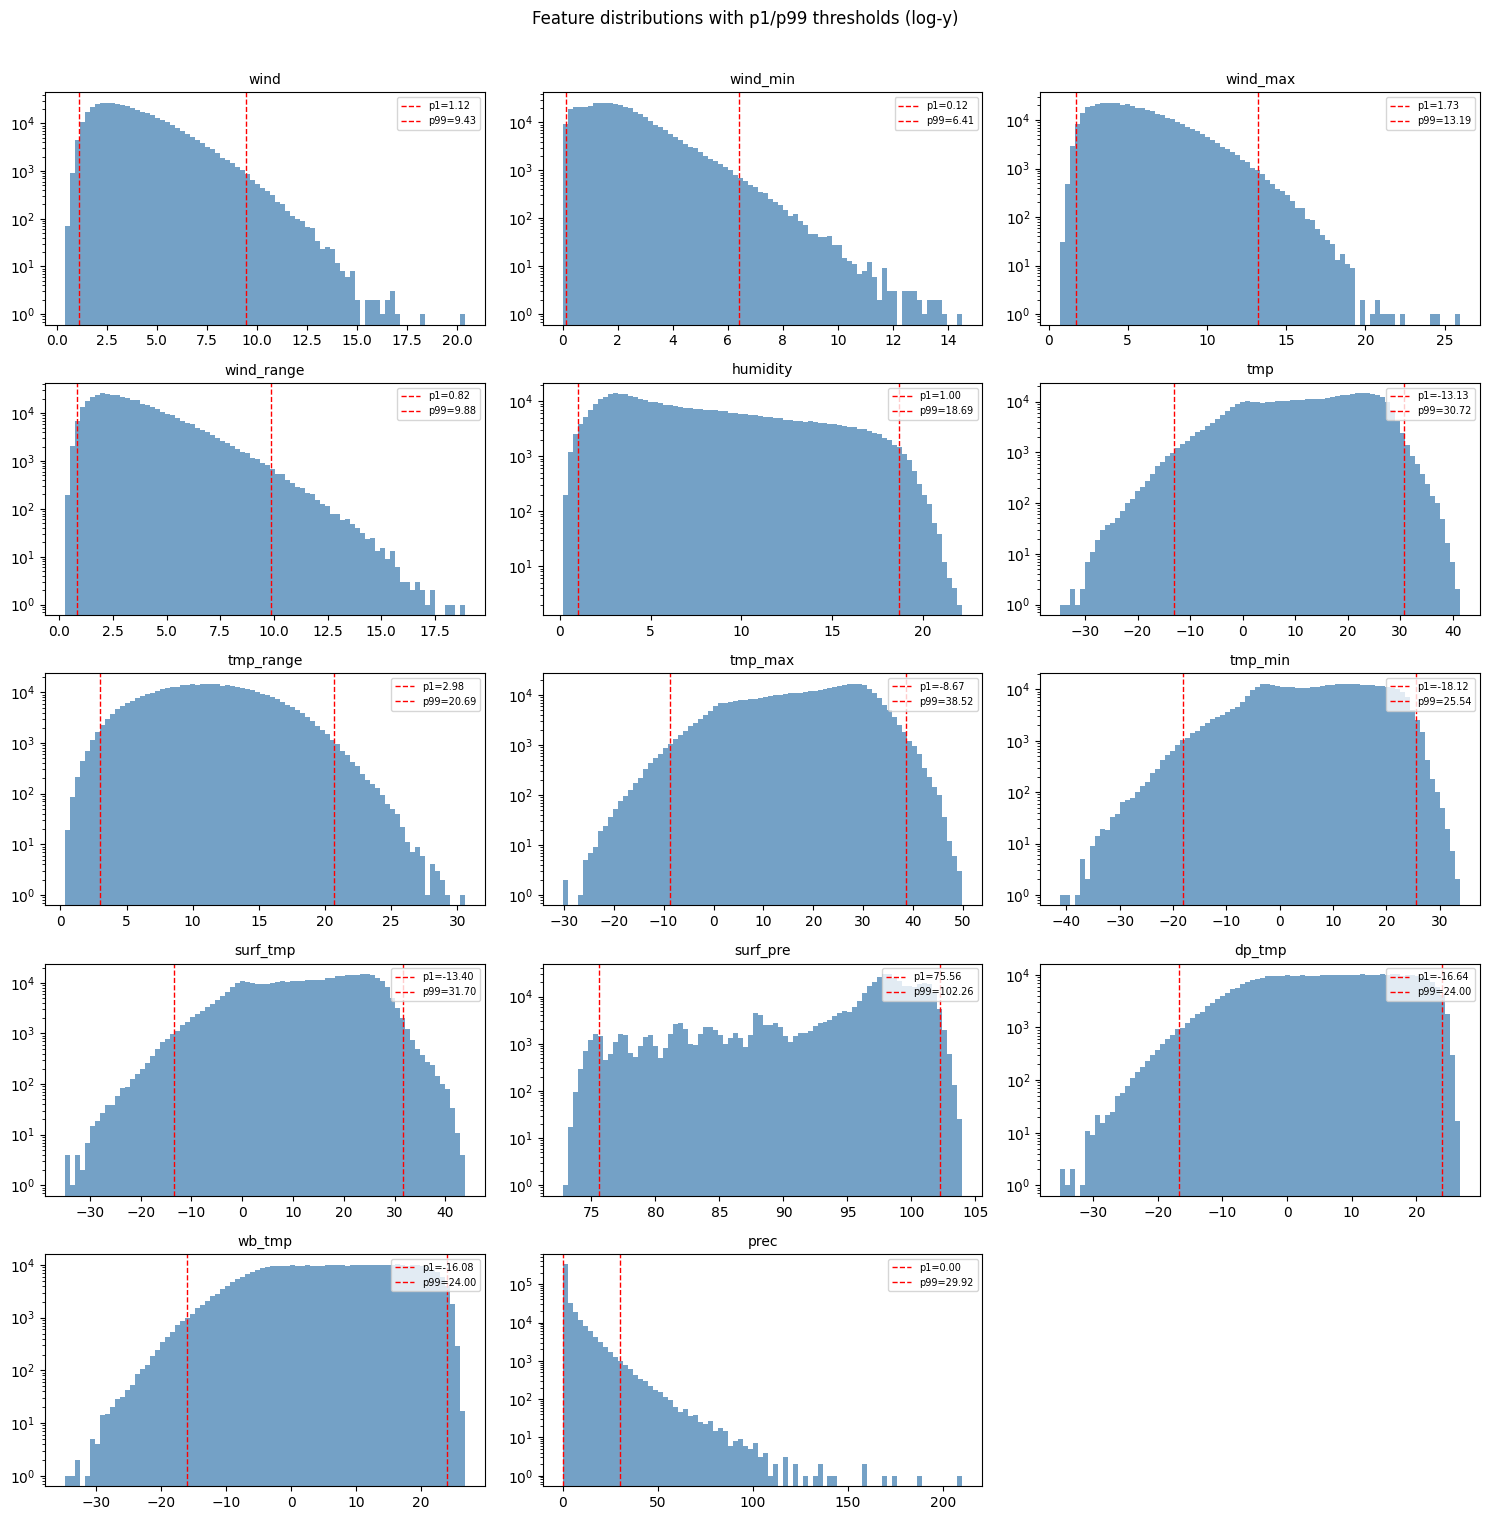

In [10]:
figs7, findings7 = eda.section_outlier_analysis(train_sample)
ALL_FINDINGS.append(findings7)
for fig in figs7:
    fig.show()

## Section 8: Distribution Shape (skewness / kurtosis → transform candidates)
Identifies features whose skewness justifies a log1p / sqrt / signed-log transform.


  Section 8 key findings — Distribution Shape
  • Log-transform candidates (|skew| > 2.0): prec(skew=5.07 → log1p)
  • Sqrt-transform candidates (|skew| ∈ (1.0, 2.0]): wind(skew=1.09), wind_min(skew=1.27), wind_range(skew=1.27), surf_pre(skew=-1.78)
  • Highest excess kurtosis (heavy-tailed): prec(kurt=45.4), wind_min(kurt=2.7), surf_pre(kurt=2.5)



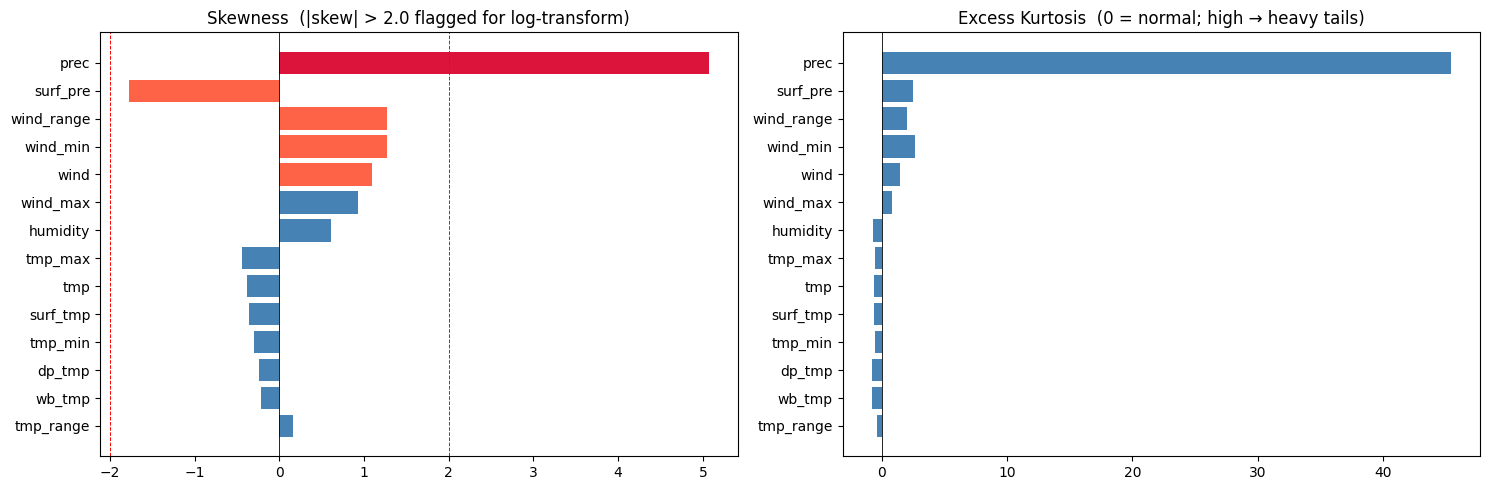

In [11]:
figs8, findings8 = eda.section_distribution_shape(train_sample)
ALL_FINDINGS.append(findings8)
for fig in figs8:
    fig.show()

## Section 9: Train vs. Test Distribution Shift (KS distance)
Quantifies how much each feature's distribution moves from train to test — the likely cause of the val/Kaggle gap.


  Section 9 key findings — Train vs. Test Distribution Shift
  • Features with KS > 0.1: tmp_max, surf_tmp, tmp, tmp_min, dp_tmp, humidity, wb_tmp, tmp_range, wind, wind_max
  • tmp_max: KS=0.242, test mean is 6.490 higher than train
  • surf_tmp: KS=0.240, test mean is 6.147 higher than train
  • tmp: KS=0.236, test mean is 5.926 higher than train
  • tmp_min: KS=0.230, test mean is 5.479 higher than train
  • dp_tmp: KS=0.186, test mean is 4.185 higher than train
  • humidity: KS=0.183, test mean is 1.790 higher than train
  • wb_tmp: KS=0.176, test mean is 3.997 higher than train
  • tmp_range: KS=0.126, test mean is 1.030 higher than train
  • wind: KS=0.110, test mean is 0.409 lower than train
  • wind_max: KS=0.102, test mean is 0.560 lower than train
  • All KS p-values are 0.0 below ~50k samples — KS is too sensitive to be a significance test here; rely on the distance value for ranking.



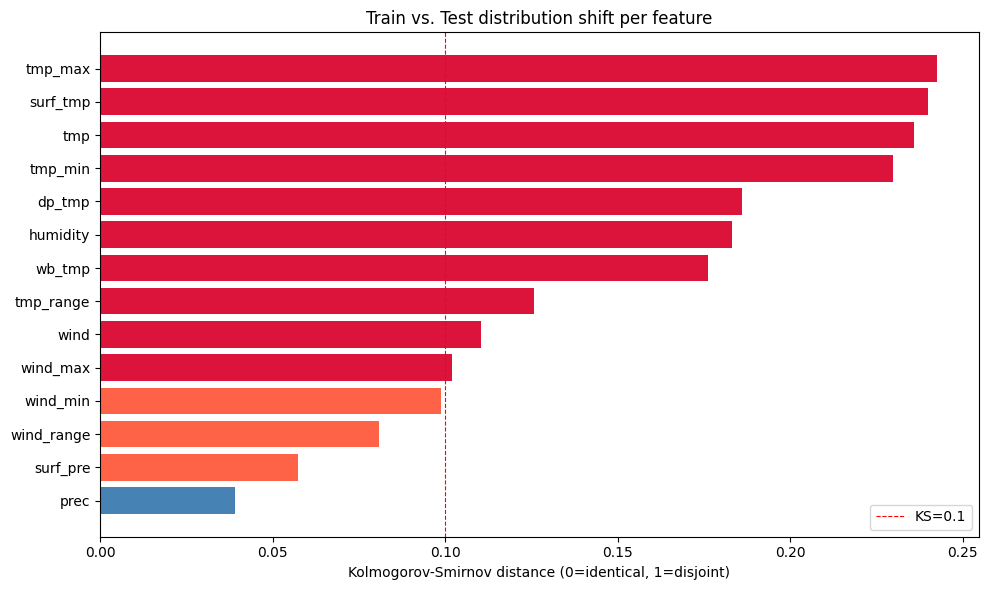

In [12]:
test_df = eda._load_test()
figs9, findings9 = eda.section_train_vs_test_shift(train_sample, test_df)
ALL_FINDINGS.append(findings9)
for fig in figs9:
    fig.show()

## Section 10: Score Transitions (Markov-style)
P(score[t+k] | score[t]) for k=1..5. Reveals persistence of zeros and severe events.


  Section 10 key findings — Score Transitions
  • P(score[t+k]=0 | score[t]=0): k=1: 0.963, k=2: 0.932, k=3: 0.907, k=4: 0.885, k=5: 0.865  → zeros are highly persistent (model can confidently predict 0 for low-risk regions)
  • P(score[t+k]≥3 | score[t]≥3) (avg over score 3-5): k=1: 0.967, k=2: 0.936, k=3: 0.907, k=4: 0.880, k=5: 0.855  → severe events DO carry over
  • P(score[t+k]≥3 | score[t]=5): k=1: 0.999, k=2: 0.997, k=3: 0.994, k=4: 0.989, k=5: 0.982



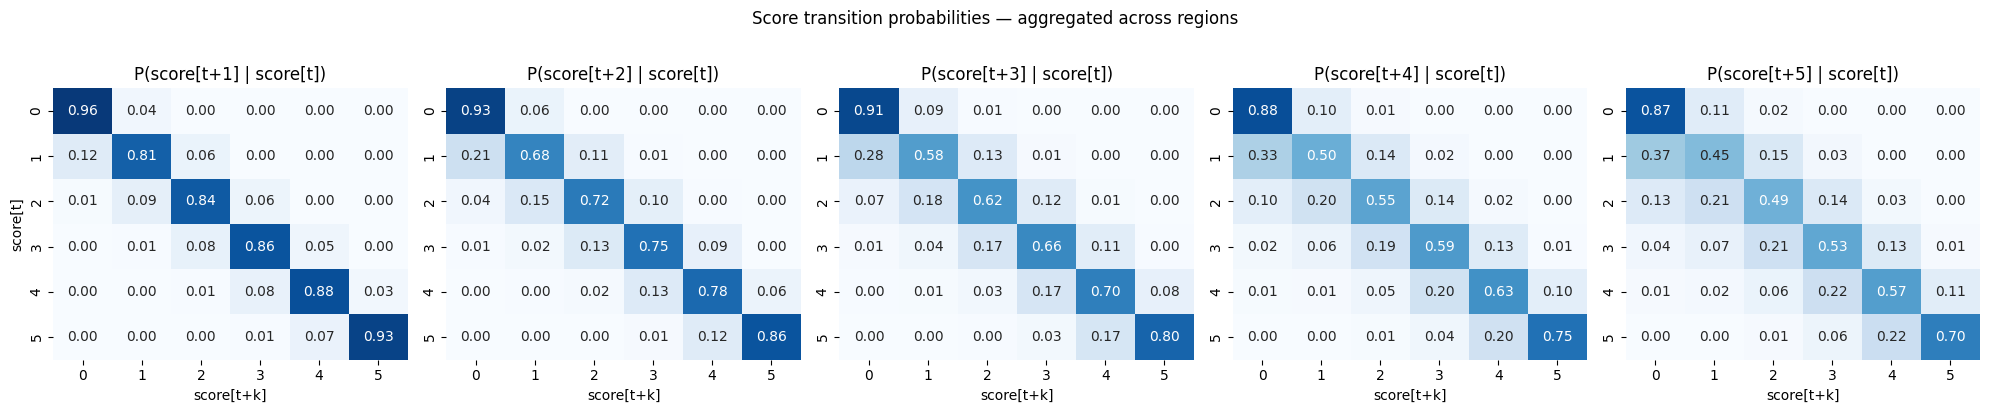

In [13]:
figs10, findings10 = eda.section_score_transitions(scored_df)
ALL_FINDINGS.append(findings10)
for fig in figs10:
    fig.show()

## Section 11: Region Clustering
K-means on per-region score patterns (zero rate, mean, max, p90). Reveals region archetypes.


  Section 11 key findings — Region Clustering
  • Cluster sizes (sorted by mean_score desc): C0=high-severity(363), C7=volatile(121), C3=volatile(402), C5=volatile(223), C1=volatile(252), C4=volatile(425), C2=moderate(161), C6=moderate(301)
  • High-severity clusters: [0]  →  363 regions (~16.1%) drive most of the rare-event MAE
  • PCA-2D explains 95.5% of region-feature variance



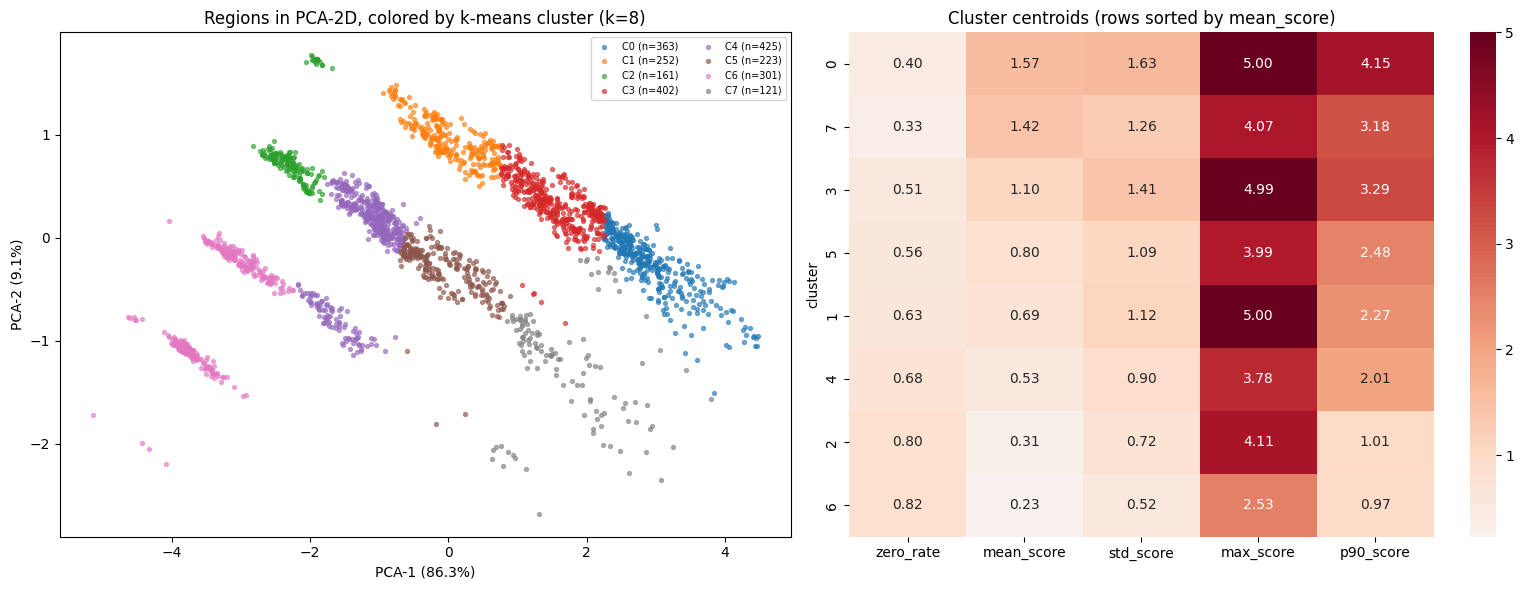

In [14]:
figs11, findings11 = eda.section_region_clustering(scored_df, n_clusters=8)
ALL_FINDINGS.append(findings11)
for fig in figs11:
    fig.show()

## Section 12: Lag Cross-Correlation
For each meteo feature × each lag k ∈ [0, 12], mean Pearson corr with score across regions. Sanity-checks `LAG_WINDOW=12`.


  Section 12 key findings — Lag Cross-Correlation
  • Top features at their BEST lag: tmp_range(lag 3, r=+0.159), tmp_max(lag 6, r=+0.106), prec(lag 4, r=-0.088), surf_tmp(lag 6, r=+0.087), tmp(lag 7, r=+0.082)
  • Features whose best lag is 0 (immediate weather → severity): wind_range
  • Features whose best lag is > 4 weeks (deeper memory matters): wind(lag 7), wind_min(lag 6), wind_max(lag 7), tmp(lag 7), tmp_max(lag 6), tmp_min(lag 8), surf_tmp(lag 6)
  • LAG_WINDOW=12 is currently used — best lags observed: min=0, max=8



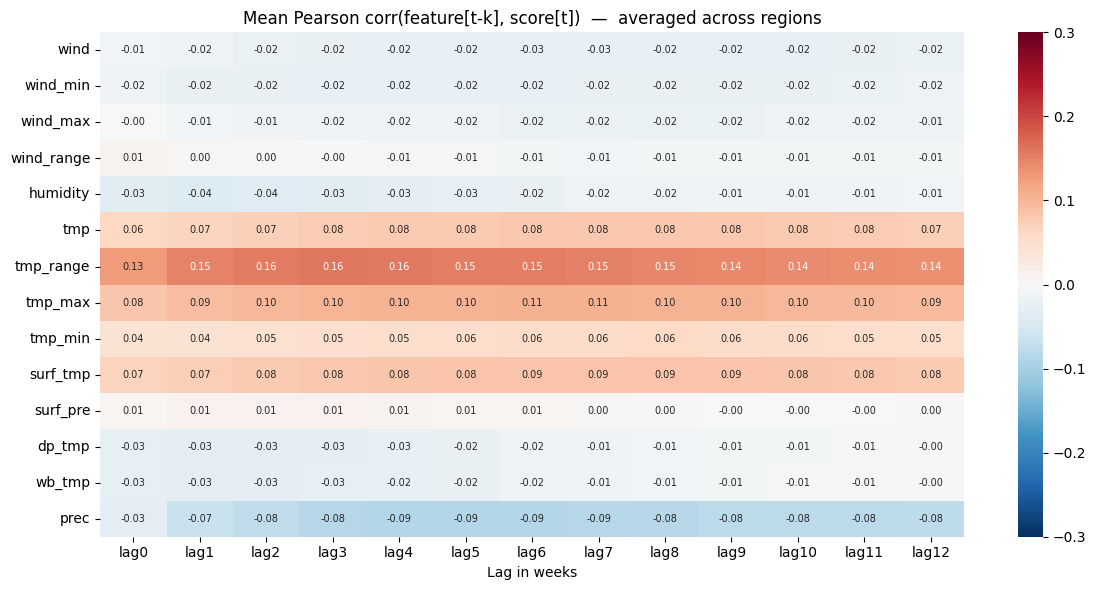

In [15]:
figs12, findings12 = eda.section_lag_cross_correlation(scored_df, max_lag=12)
ALL_FINDINGS.append(findings12)
for fig in figs12:
    fig.show()

## Auto-aggregated EDA Findings
Single consolidated view of every section's structured findings.

In [16]:
eda.print_aggregated_findings(ALL_FINDINGS)


  AGGREGATED EDA FINDINGS

  Section 1:
    n_train_columns: 20
    n_test_columns: 19
    test_rows_per_region_uniform: True
    test_rows_per_region: 91
    train_sample_null_in_score: 37584
    train_sample_scored_frac: 0.1427007299270073
    submission_shape: [2248, 6]

  Section 2:
    zero_rate: 0.5963
    mean_nonzero_score: 2.0702
    score_counts: <6-entry dict, see section output>
    score_pct: <6-entry dict, see section output>
    global_mean_per_region_score: 0.8357
    acf_first_lag_below_0.05: <complex value, see section output>
    acf_region: R1

  Section 3:
    top_feature_score_corr: <3-entry dict, see section output>
    top_collinear_pairs: <complex value, see section output>

  Section 4:
    n_regions_plotted: 3
    mean_score_by_month: <12-entry dict, see section output>
    peak_month: 11
    trough_month: 3
    peak_minus_trough: 0.3458094144661309

  Section 5:
    top_positive_feature_score_corr: <3-entry dict, see section output>
    top_negative_feature